# 01 · Comprensión de los datos

**Proyecto:** Identificación de hogares en situación de pobreza monetaria mediante aprendizaje automático, a partir de características observables del hogar, utilizando la Encuesta Nacional de Hogares (ENAHO 2025) del INEI.

## El proyecto en breve

**Problema.** Los programas sociales, como Juntos y Pensión 65, deben identificar qué hogares son pobres para llegar a ellos. Medir la pobreza monetaria exige una encuesta larga sobre el gasto del hogar, así que en la práctica se decide con características que se pueden observar en una visita. Esa decisión comete dos errores: deja fuera a hogares pobres (**exclusión**) e incluye a hogares que no lo son (**inclusión**).

**Pregunta de investigación.** ¿Un modelo de aprendizaje automático entrenado solo con características observables del hogar identifica a los hogares pobres mejor que una regla de focalización simple?

**Recorrido.** Los cinco cuadernos cubren la parte de datos e inteligencia artificial del proyecto, siguiendo las fases 2 a 5 de CRISP-DM:

| Cuaderno | Fase de CRISP-DM | Pregunta que responde |
|---|---|---|
| 01 · Comprensión de los datos | Comprensión de los datos | ¿De dónde vienen los datos y qué tan confiables son? |
| 02 · Análisis exploratorio | Comprensión de los datos | ¿Qué características se asocian con la pobreza? ¿Basta una regla simple? |
| 03 · Preparación | Preparación de los datos | ¿Cómo se preparan los datos sin fuga de información? |
| 04 · Modelado | Modelado | ¿Qué algoritmo identifica mejor a los hogares pobres? |
| 05 · Evaluación | Evaluación | ¿El modelo elegido funciona con hogares nuevos y en otro año? ¿Es explicable y justo? |

El código reutilizable (descarga, construcción de variables, preprocesamiento, modelos y métricas) está en la carpeta `src/`. Los cuadernos lo usan y muestran qué se hace, por qué y con qué resultado. El planteamiento del problema y la discusión están en el informe; el prototipo (`app/`) y las pruebas (`tests/`) se describen en el README.

> Cuando el texto dice «cuaderno 06 del curso», se refiere a los cuadernos vistos en clase. «Cuaderno 03», sin más, es un cuaderno de este proyecto.

## Este cuaderno

Corresponde a la **Fase 2 de CRISP-DM: Comprensión de los datos**. Su objetivo es responder, con evidencia, la pregunta *¿de dónde provienen los datos y qué tan confiables son?*

**Entrada:** los microdatos de la ENAHO, descargados del portal del INEI. **Salida:** los datasets de hogares de 2025 y 2024 (`data/processed/`) y el diccionario de datos (`docs/diccionario_datos.csv`).

En este cuaderno vamos a:

1. descargar los datos directamente desde la fuente oficial (INEI);
2. conocer los módulos de la encuesta y la unidad de análisis;
3. **verificar la procedencia** reproduciendo las cifras oficiales de pobreza publicadas por el INEI;
4. analizar la variable objetivo;
5. construir el dataset de hogares con las variables predictoras seleccionadas;
6. elaborar la ficha del dataset y el diccionario de datos;
7. evaluar la calidad de los datos: completitud, unicidad, validez, consistencia, exactitud y actualidad;
8. construir y verificar el dataset de la ENAHO 2024, que se usa en la validación temporal.

## Configuración del entorno

La siguiente celda permite ejecutar el cuaderno tanto en **Google Colab** como en una instalación local de Python. En Colab se monta Google Drive y se asume que la carpeta del proyecto está en `MyDrive/proyecto-pobreza-ia`; si está en otra, basta con cambiar `RUTA_PROYECTO`. La celda comprueba que está en la carpeta correcta antes de continuar.

In [1]:
# ==========================================================
# CONFIGURACIÓN DEL ENTORNO (funciona en Google Colab y en local)
# ==========================================================
# En Colab, la primera vez conviene instalar las versiones del proyecto y reiniciar la sesión:
# !pip install -r /content/drive/MyDrive/proyecto-pobreza-ia/requirements.txt
import os
import sys

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    # En Colab: montamos Google Drive y nos ubicamos en la carpeta del proyecto
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_PROYECTO = "/content/drive/MyDrive/proyecto-pobreza-ia"  # ajustar si el proyecto está en otra carpeta
    os.chdir(RUTA_PROYECTO)
elif os.path.basename(os.getcwd()) == "notebooks":
    # En local: si el notebook se abre desde la carpeta notebooks/, subimos a la raíz
    os.chdir("..")

# Comprobamos que estamos en la raíz del proyecto y permitimos importar su código (carpeta src/)
assert os.path.isdir("src"), "No se encuentra la carpeta src/: revisa RUTA_PROYECTO"
sys.path.insert(0, os.getcwd())
print("Entorno:", "Google Colab" if EN_COLAB else "local", "| Carpeta del proyecto:", os.path.basename(os.getcwd()))

Entorno: local | Carpeta del proyecto: proyecto-pobreza-ia


In [2]:
# Librerías para análisis de datos y visualización
import pandas as pd
import matplotlib.pyplot as plt

# Código propio del proyecto (carpeta src/)
from src.data.descargar import descargar_enaho, MODULOS
from src.data.cargar import cargar_modulos
from src.features.construir import (
    construir_dataset_hogares, diccionario_de_datos, CLAVES_HOGAR, ARTICULOS_EQUIPAMIENTO,
    VARIABLES_NUMERICAS, VARIABLES_CATEGORICAS, VARIABLES_BINARIAS, VARIABLES_PREDICTORAS,
)
from src.visualizacion import aplicar_estilo, guardar_figura, AZUL, TEXTO_SECUNDARIO

aplicar_estilo()
pd.set_option("display.max_columns", 50)

## Fuente de los datos

Utilizamos la **Encuesta Nacional de Hogares (ENAHO)**, que el Instituto Nacional de Estadística e Informática (INEI) ejecuta de forma continua desde 1995. Es la **fuente oficial con la que el Estado peruano mide la pobreza monetaria**, por lo que la variable objetivo del proyecto no es una etiqueta inventada, sino la clasificación oficial del INEI.

Los microdatos se publican en el portal [proyectos.inei.gob.pe/microdatos](https://proyectos.inei.gob.pe/microdatos/) de forma anónima (sin nombres ni direcciones) para proteger el secreto estadístico. La encuesta está organizada en **módulos**; este proyecto utiliza los siguientes:

| Módulo | Contenido | Uso en el proyecto |
|---|---|---|
| 01 (100) | Características de la vivienda y del hogar | Variables predictoras |
| 02 (200) | Características de los miembros del hogar | Variables predictoras (composición del hogar) |
| 03 (300) | Educación | Variables predictoras (nivel educativo) |
| 18 (612) | Equipamiento del hogar | Variables predictoras (artefactos y vehículos) |
| 34 | Sumaria: variables calculadas por el INEI | **Variable objetivo** (condición de pobreza), tamaño del hogar y ubicación |
| 37 (700) | Programas sociales | Solo para analizar el problema (no se usa como predictora) |

La siguiente celda descarga los módulos de la **ENAHO 2025**, la edición más reciente disponible (publicada por el INEI en mayo de 2026).

In [3]:
# Descargamos los módulos de la ENAHO 2025 desde el portal del INEI.
# Si los archivos ya existen en data/raw, no se vuelven a descargar.
rutas_modulos = descargar_enaho(anio=2025, carpeta_destino="data/raw")

for modulo, ruta in rutas_modulos.items():
    print(f"Módulo {modulo} ({MODULOS[modulo]}):\n   {ruta}")

Módulo 01 (Características de la vivienda y del hogar):
   data/raw\enaho_2025\1031-Modulo01
Módulo 02 (Características de los miembros del hogar):
   data/raw\enaho_2025\1031-Modulo02
Módulo 03 (Educación):
   data/raw\enaho_2025\1031-Modulo03
Módulo 18 (Equipamiento del hogar):
   data/raw\enaho_2025\1031-Modulo18
Módulo 34 (Sumarias (variables calculadas, incluye la condición de pobreza)):
   data/raw\enaho_2025\1031-Modulo34
Módulo 37 (Programas sociales (solo para el análisis del problema, no como predictora)):
   data/raw\enaho_2025\1031-Modulo37


### Interpretación de la descarga

Cada módulo se descarga como un archivo ZIP y se descomprime en `data/raw/enaho_2025/`. Además del CSV de datos, cada ZIP incluye el **diccionario de variables** y la **ficha técnica** oficiales, que usamos para interpretar cada código.

Como la descarga se hace por código desde la fuente oficial, **cualquier persona puede reconstruir exactamente el mismo dataset**. Este es el mecanismo de acceso reproducible que exige el proyecto.

## Carga de los módulos y unidad de análisis

La **unidad de análisis es el hogar**. En la ENAHO, un hogar se identifica con tres variables que funcionan como llave: `CONGLOME` (conglomerado), `VIVIENDA` y `HOGAR`. Los módulos de personas (200 y 300) agregan `CODPERSO`, que identifica a cada miembro.

Un detalle técnico importante: el INEI cambió el formato de los CSV entre años. En 2025 usa `;` como separador y coma decimal, mientras que en 2024 usaba `,` y punto decimal. La función `cargar_modulos` detecta el formato automáticamente.

In [4]:
# Cargamos todos los módulos en un diccionario de DataFrames
modulos = cargar_modulos(anio=2025, carpeta_raw="data/raw")

# Resumen del tamaño de cada módulo
resumen_modulos = pd.DataFrame({
    "filas": {nombre: df.shape[0] for nombre, df in modulos.items()},
    "columnas": {nombre: df.shape[1] for nombre, df in modulos.items()},
})
resumen_modulos

,filas,columnas
vivienda,44599,336
miembros,115145,40
educacion,104446,495
equipamiento,943656,24
sumaria,33702,161
programas,40338,20


In [5]:
# El módulo 100 incluye todas las viviendas visitadas, no solo las entrevistadas.
# La variable RESULT indica el resultado final de la entrevista.
etiquetas_resultado = {1: "Completa", 2: "Incompleta", 3: "Rechazo", 4: "Ausente",
                       5: "Vivienda desocupada", 7: "Otro"}

resultado = modulos["vivienda"]["RESULT"].map(etiquetas_resultado).value_counts()
resultado.to_frame("viviendas")

,viviendas
RESULT,
Completa,27260
Incompleta,6442
Otro,5976
Vivienda desocupada,3041
Rechazo,1586
Ausente,294


### Interpretación de los módulos

- La **sumaria** tiene **33 702 filas**, una por cada hogar con entrevista completa o incompleta. Este es el universo de hogares del proyecto.
- El módulo de **vivienda** tiene 44 599 filas porque incluye también las viviendas donde no se logró la entrevista (rechazos, ausentes y viviendas desocupadas). La suma de entrevistas completas (27 260) e incompletas (6 442) es exactamente 33 702, lo que confirma que la sumaria y el módulo de vivienda son coherentes.
- Los módulos de **miembros** (115 145 filas) y **educación** (104 446 filas) están a nivel de persona. Para usarlos, los resumiremos a nivel de hogar.
- El módulo de **equipamiento** tiene 943 656 filas: 28 artículos por cada uno de los 33 702 hogares (28 × 33 702 = 943 656).

## Verificación de la procedencia: reproducción de las cifras oficiales del INEI

Una forma rigurosa de demostrar que los datos son reales y que los estamos procesando correctamente es **reproducir las cifras oficiales publicadas por el INEI**.

El 5 de mayo de 2026, el INEI presentó el informe *Perú: Evolución de la Pobreza Monetaria 2016-2025*, que reporta para 2025 una pobreza monetaria de **25,7 %** a nivel nacional, **23,4 %** en el área urbana y **35,5 %** en el área rural, con Cajamarca (41,0 %), Loreto (40,1 %), Puno (37,5 %), Pasco (36,4 %) y Huánuco (35,7 %) como los departamentos más pobres.

Estas cifras se expresan en **porcentaje de personas**, por eso cada hogar se pondera con su factor de expansión (`FACTOR07`) multiplicado por su número de miembros (`MIEPERHO`).

In [6]:
sumaria = modulos["sumaria"]


def tasa_pobreza(sumaria, filtro=None):
    # Porcentaje de PERSONAS pobres, como lo publica el INEI: cada hogar pesa su factor de expansión × sus miembros
    if filtro is not None:
        sumaria = sumaria[filtro]
    peso = sumaria["FACTOR07"] * sumaria["MIEPERHO"]
    es_pobre = sumaria["POBREZA"] <= 2  # 1 = pobre extremo, 2 = pobre no extremo
    return (es_pobre * peso).sum() / peso.sum() * 100


def comparar_con_inei(filas):
    # Tabla con la cifra calculada, la oficial y su diferencia (en puntos porcentuales)
    tabla = pd.DataFrame(filas, columns=["ámbito", "pobreza_calculada_%", "pobreza_oficial_INEI_%"])
    tabla["pobreza_calculada_%"] = tabla["pobreza_calculada_%"].round(1)
    tabla["diferencia"] = (tabla["pobreza_calculada_%"] - tabla["pobreza_oficial_INEI_%"]).round(1)
    return tabla


area_rural = sumaria["ESTRATO"] >= 6  # los estratos 6, 7 y 8 corresponden al área rural
departamento = sumaria["UBIGEO"].astype(str).str.zfill(6).str[:2].astype(int)  # dos primeros dígitos del ubigeo

comparar_con_inei([
    ("Nacional", tasa_pobreza(sumaria), 25.7),
    ("Urbana", tasa_pobreza(sumaria, ~area_rural), 23.4),
    ("Rural", tasa_pobreza(sumaria, area_rural), 35.5),
    ("Cajamarca", tasa_pobreza(sumaria, departamento == 6), 41.0),
    ("Loreto", tasa_pobreza(sumaria, departamento == 16), 40.1),
    ("Puno", tasa_pobreza(sumaria, departamento == 21), 37.5),
    ("Pasco", tasa_pobreza(sumaria, departamento == 19), 36.4),
    ("Huánuco", tasa_pobreza(sumaria, departamento == 10), 35.7),
])

,ámbito,pobreza_calculada_%,pobreza_oficial_INEI_%,diferencia
0,Nacional,25.7,25.7,0.0
1,Urbana,23.4,23.4,0.0
2,Rural,35.5,35.5,0.0
3,Cajamarca,41.0,41.0,0.0
4,Loreto,40.1,40.1,0.0
5,Puno,37.5,37.5,0.0
6,Pasco,36.4,36.4,0.0
7,Huánuco,35.7,35.7,0.0


### Interpretación de la verificación

Las cifras calculadas a partir de los microdatos **coinciden exactamente** (diferencia 0,0) con las publicadas oficialmente por el INEI en los ocho ámbitos comparados.

Esto demuestra tres cosas:

1. **Los datos son reales y oficiales**: son los mismos con los que el Estado mide la pobreza.
2. **La procedencia es verificable**: cualquier investigador puede descargar los mismos archivos y obtener los mismos valores.
3. **La lectura y unión de los datos es correcta**: no hay errores en el separador, los decimales, las llaves ni los factores de expansión.

A partir de aquí, las estimaciones de *porcentaje de personas* usarán el factor de expansión. En cambio, el **modelo de aprendizaje automático trabaja a nivel de hogar**, porque la decisión de focalización se toma por hogar.

## Variable objetivo

La variable `POBREZA` de la sumaria clasifica a cada hogar en tres categorías:

- `1`: pobre extremo (su gasto por persona no cubre ni la canasta básica de alimentos);
- `2`: pobre no extremo (cubre los alimentos, pero no la canasta básica total);
- `3`: no pobre.

Para el proyecto construimos una **variable objetivo binaria** `pobre`: vale `1` si el hogar es pobre extremo o pobre no extremo, y `0` si no es pobre. Así se alinea con la pregunta práctica de la focalización: *¿este hogar debería ser priorizado por un programa social?*

In [7]:
# Distribución de la clasificación oficial de pobreza (a nivel de hogar, sin ponderar)
etiquetas_pobreza = {1: "Pobre extremo", 2: "Pobre no extremo", 3: "No pobre"}

distribucion = sumaria["POBREZA"].map(etiquetas_pobreza).value_counts().to_frame("hogares")
distribucion["porcentaje"] = (distribucion["hogares"] / distribucion["hogares"].sum() * 100).round(1)
distribucion

,hogares,porcentaje
POBREZA,,
No pobre,27598,81.9
Pobre no extremo,4922,14.6
Pobre extremo,1182,3.5


In [8]:
# Variable objetivo binaria
pobre = (sumaria["POBREZA"] <= 2).astype(int)
print("Hogares pobres (pobre = 1):", pobre.sum(), f"({pobre.mean() * 100:.1f} %)")
print("Hogares no pobres (pobre = 0):", (pobre == 0).sum(), f"({(1 - pobre.mean()) * 100:.1f} %)")

# Tamaño promedio del hogar según su condición de pobreza
print("\nMiembros promedio por hogar:")
print(sumaria.groupby(pobre)["MIEPERHO"].mean().rename({0: "No pobre", 1: "Pobre"}).round(2))

Hogares pobres (pobre = 1): 6104 (18.1 %)
Hogares no pobres (pobre = 0): 27598 (81.9 %)

Miembros promedio por hogar:
POBREZA
No pobre    2.99
Pobre       4.06
Name: MIEPERHO, dtype: float64


### Interpretación de la variable objetivo

- De los 33 702 hogares, **6 104 (18,1 %) son pobres** y 27 598 (81,9 %) no lo son.
- El porcentaje de **hogares** pobres (18,1 %) es menor que el porcentaje de **personas** pobres (25,7 %) porque **los hogares pobres son más grandes**: tienen en promedio 4,06 miembros, frente a 2,99 de los no pobres.
- La clase positiva (pobre) es **minoritaria**: por cada hogar pobre hay unos 4,5 no pobres. Esto tiene dos consecuencias para el modelado:
  - el *accuracy* no basta, porque un modelo que dijera "nadie es pobre" acertaría el 81,9 % de las veces sin servir para nada;
  - habrá que evaluar con *precision*, *recall*, *F1* y *ROC-AUC*, y considerar `class_weight="balanced"`.

## Construcción del dataset de hogares

A partir de los módulos construimos un único DataFrame con **una fila por hogar**. La función `construir_dataset_hogares` (en `src/features/construir.py`):

1. toma el tamaño del hogar, la ubicación y la variable objetivo de la **sumaria**;
2. agrega las características de la **vivienda** (materiales, agua, desagüe, electricidad, combustible, comunicaciones);
3. resume el módulo de **miembros**: edad y sexo del jefe(a), número de menores de 14 años y de mayores de 65;
4. resume el módulo de **educación**: nivel educativo del jefe(a) y máximo nivel entre los adultos;
5. convierte el módulo de **equipamiento** en columnas 0/1 (refrigeradora, computadora, lavadora, etc.) y un total de artículos;
6. calcula **variables derivadas**: personas por habitación (hacinamiento) y tasa de dependencia.

### Criterio de selección de variables

Solo se incluyen **características observables**: las que un encuestador puede verificar en una visita, como las usadas por los sistemas de focalización basados en características del hogar (*proxy means test*).

Se **excluyen deliberadamente**, para evitar *data leakage*:

- **ingresos y gastos** (`INGHOG*`, `GASHOG*`, `GRU*`, etc.): son la base con la que el INEI calcula la pobreza, así que usarlos sería darle la respuesta al modelo;
- **líneas de pobreza y variables derivadas** (`LINEA`, `LINPE`, `POBREZAV`, `ESTRSOCIAL`);
- **montos monetarios de la vivienda** (alquiler pagado o estimado);
- **programas sociales**: se asignan *porque* el hogar fue clasificado como pobre, así que son consecuencia de la pobreza y no una característica previa.

In [9]:
# Construimos el dataset a nivel de hogar
hogares = construir_dataset_hogares(modulos)

print("Dimensiones del dataset de hogares:", hogares.shape)
print("Variables predictoras:", len(VARIABLES_PREDICTORAS))
print(f"  - numéricas: {len(VARIABLES_NUMERICAS)}")
print(f"  - categóricas: {len(VARIABLES_CATEGORICAS)}")
print(f"  - binarias: {len(VARIABLES_BINARIAS)}")

hogares.head()

Dimensiones del dataset de hogares: (33702, 43)
Variables predictoras: 36
  - numéricas: 10
  - categóricas: 10
  - binarias: 16


,CONGLOME,VIVIENDA,HOGAR,ubigeo,factor07,pobreza_inei,n_miembros,n_habitaciones,personas_por_habitacion,jefe_edad,n_menores_14,n_mayores_65,tasa_dependencia,educacion_jefe,max_educacion_adultos,n_equipos,tipo_vivienda,material_paredes,material_piso,material_techo,tenencia_vivienda,fuente_agua,desague,combustible_cocina,dominio,departamento,area_rural,jefe_mujer,tiene_electricidad,tiene_telefono_fijo,tiene_celular,tiene_tv_cable,tiene_internet,tiene_radio,tiene_tv_color,tiene_computadora,tiene_cocina_gas,tiene_refrigeradora,tiene_lavadora,tiene_microondas,tiene_auto,tiene_motocicleta,pobre
0,15009,12,11,010101,87.28569,3,2,4.0,0.5,45.0,0,0,0.0,11.0,11.0,6.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,4.0,1.0,0,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0
1,15009,25,11,010101,87.28569,3,6,3.0,2.0,42.0,2,0,0.5,6.0,6.0,6.0,1.0,3.0,5.0,4.0,2.0,1.0,1.0,2.0,4.0,1.0,0,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,15009,49,11,010101,87.28569,3,3,3.0,1.0,44.0,1,0,0.5,8.0,10.0,9.0,1.0,1.0,5.0,1.0,2.0,1.0,1.0,2.0,4.0,1.0,0,1,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0
3,15009,61,11,010101,87.28569,3,1,2.0,0.5,78.0,0,1,1.0,1.0,1.0,5.0,1.0,3.0,5.0,5.0,2.0,1.0,1.0,2.0,4.0,1.0,0,1,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
4,15009,74,11,010101,87.28569,3,3,1.0,3.0,33.0,1,0,0.5,10.0,10.0,8.0,4.0,3.0,5.0,4.0,1.0,1.0,2.0,2.0,4.0,1.0,0,1,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0


### Interpretación del dataset construido

El dataset final tiene **33 702 hogares** y **43 columnas**:

- **36 variables predictoras**: 10 numéricas, 10 categóricas y 16 binarias;
- **1 variable objetivo** (`pobre`);
- **6 columnas de identificación y análisis** (`CONGLOME`, `VIVIENDA`, `HOGAR`, `ubigeo`, `factor07` y `pobreza_inei`), que **nunca entran al modelo**. `pobreza_inei` es la misma información que la variable objetivo, y usarla como predictora sería *data leakage*.

Las variables categóricas se conservan con los códigos numéricos del INEI (por ejemplo, `material_piso = 6` significa "tierra"). En la etapa de preparación se transformarán con *One-Hot Encoding*, para que el modelo no interprete los códigos como cantidades.

## Ficha del dataset

| Característica | Descripción |
|---|---|
| **Nombre** | Encuesta Nacional de Hogares (ENAHO) 2025, metodología actualizada |
| **Fuente** | Instituto Nacional de Estadística e Informática (INEI), portal de microdatos |
| **Propietario** | INEI, Estado peruano |
| **Fecha de adquisición** | 24 de septiembre de 2026 (descarga automatizada con `src/data/descargar.py`) |
| **Periodo** | Enero a diciembre de 2025 (encuesta continua) |
| **Cobertura** | Nacional: 25 departamentos, áreas urbana y rural |
| **Registros** | 33 702 hogares |
| **Variables** | 36 predictoras + 1 objetivo + 6 de identificación y análisis |
| **Unidad de análisis** | Hogar (llave `CONGLOME` + `VIVIENDA` + `HOGAR`) |
| **Variable objetivo** | `pobre` (1 = pobre extremo o no extremo; 0 = no pobre), derivada de `POBREZA` |
| **Formato** | CSV (separador `;`, coma decimal, codificación latin-1) |
| **Procedencia** | Encuesta por muestreo probabilístico, estratificado y por conglomerados, aplicada por entrevista directa |
| **Licencia / permiso** | Microdatos de acceso libre y anónimos; protegidos por el secreto estadístico (D. Leg. 604 y D. S. 043-2001-PCM); uso permitido citando la fuente |

## Diccionario de datos

La siguiente tabla describe cada columna del dataset, su tipo y su origen en la ENAHO. Se guarda en `docs/diccionario_datos.csv` para incluirla como **Anexo C** del informe.

In [10]:
diccionario = diccionario_de_datos()
os.makedirs("docs", exist_ok=True)
diccionario.to_csv("docs/diccionario_datos.csv", index=False, encoding="utf-8-sig")

pd.set_option("display.max_colwidth", 90)
diccionario

,variable,tipo,origen_enaho,descripcion
0,CONGLOME,Identificación (no entra al modelo),Todas,Número de conglomerado (parte de la llave del hogar)
1,VIVIENDA,Identificación (no entra al modelo),Todas,Número de vivienda (parte de la llave del hogar)
2,HOGAR,Identificación (no entra al modelo),Todas,Número de hogar (parte de la llave del hogar)
3,ubigeo,Identificación (no entra al modelo),Sumaria,"Código de ubicación geográfica del INEI (departamento, provincia, distrito)"
4,factor07,Identificación (no entra al modelo),Sumaria,Factor de expansión del hogar; solo para estimaciones poblacionales
5,pobreza_inei,Identificación (no entra al modelo),Sumaria POBREZA,"Condición de pobreza oficial: 1 pobre extremo, 2 pobre no extremo, 3 no pobre"
6,n_miembros,Numérica,Sumaria MIEPERHO,Número de miembros del hogar
7,n_habitaciones,Numérica,Mód. 100 P104,"Habitaciones de la vivienda, sin contar baño, cocina ni pasadizos"
8,personas_por_habitacion,Numérica,Derivada,n_miembros / n_habitaciones (hacinamiento)
9,jefe_edad,Numérica,Mód. 200 P208A,Edad del jefe(a) del hogar en años


## Calidad de los datos

Evaluamos las seis dimensiones de calidad que exige el proyecto: **completitud, unicidad, validez, consistencia, exactitud y actualidad**.

### 1. Completitud: ¿cuántos valores faltantes existen?

In [11]:
# Porcentaje de valores faltantes por variable predictora
faltantes = hogares[VARIABLES_PREDICTORAS].isna().sum().to_frame("faltantes")
faltantes["porcentaje"] = (faltantes["faltantes"] / len(hogares) * 100).round(2)
faltantes = faltantes[faltantes["faltantes"] > 0].sort_values("porcentaje", ascending=False)

print("Variables sin ningún faltante:", len(VARIABLES_PREDICTORAS) - len(faltantes), "de", len(VARIABLES_PREDICTORAS))
print(f"Hogares con al menos un faltante: {hogares[VARIABLES_PREDICTORAS].isna().any(axis=1).mean() * 100:.1f} %")
faltantes

Variables sin ningún faltante: 17 de 36
Hogares con al menos un faltante: 12.0 %


,faltantes,porcentaje
tiene_motocicleta,2478,7.35
tiene_lavadora,2112,6.27
tiene_radio,1763,5.23
tiene_refrigeradora,1423,4.22
tiene_microondas,1344,3.99
tiene_auto,1337,3.97
combustible_cocina,1290,3.83
tiene_computadora,1223,3.63
tiene_cocina_gas,1050,3.12
tiene_tv_color,724,2.15


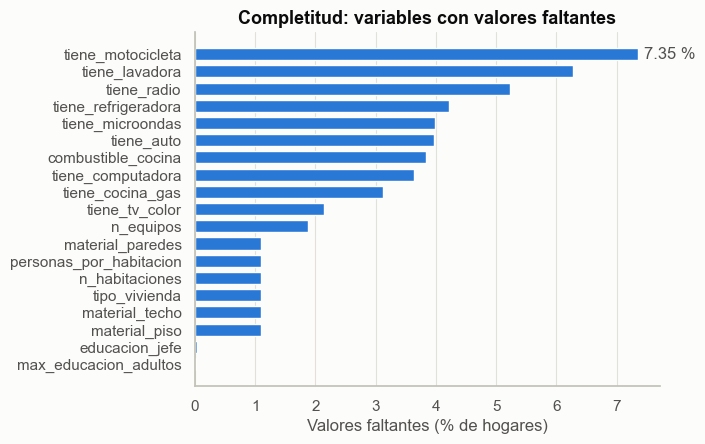

In [12]:
# Gráfico de faltantes por variable (una sola serie, un solo color)
fig, ax = plt.subplots(figsize=(6, 4.6))
ax.barh(faltantes.index, faltantes["porcentaje"], color=AZUL, height=0.7)
ax.invert_yaxis()
ax.set_xlabel("Valores faltantes (% de hogares)")
ax.set_title("Completitud: variables con valores faltantes")
ax.grid(axis="y", visible=False)

# Etiquetamos solo el valor más alto
ax.text(faltantes["porcentaje"].iloc[0] + 0.1, 0, f'{faltantes["porcentaje"].iloc[0]:.2f} %',
        va="center", color=TEXTO_SECUNDARIO)
guardar_figura("01_completitud_faltantes")
plt.show()

### Interpretación de la completitud

- **17 de las 36 variables no tienen ningún faltante**. Entre ellas están las que describen servicios básicos (agua, desagüe, electricidad), comunicaciones, composición del hogar y ubicación.
- El mayor porcentaje de faltantes está en **motocicleta (7,35 %)** y **lavadora (6,27 %)**. En el módulo 612, esos casos tienen el código 9 ("valor faltante"), es decir, el informante no respondió por ese artículo.
- Un grupo de **369 hogares (1,1 %)** no tiene datos de materiales ni habitaciones de la vivienda: son entrevistas incompletas en esa sección.
- En total, el **12 % de los hogares** tiene al menos un faltante. Eliminarlos descartaría información valiosa, así que se **imputarán dentro del pipeline** (mediana para numéricas y valor más frecuente para categóricas y binarias). Así la imputación se aprende solo con los datos de entrenamiento y no hay fuga de información.

### 2. Unicidad: ¿existen duplicados?

In [13]:
duplicados_llave = hogares.duplicated(subset=CLAVES_HOGAR).sum()
print("Hogares con la llave repetida:", duplicados_llave)

# Registros idénticos en todas las variables (sin contar la llave ni el factor de expansión)
columnas_contenido = [c for c in hogares.columns if c not in CLAVES_HOGAR + ["ubigeo", "factor07"]]
print("Hogares con contenido idéntico:", hogares.duplicated(subset=columnas_contenido).sum())

Hogares con la llave repetida: 0
Hogares con contenido idéntico: 0


### Interpretación de la unicidad

No existen hogares con la llave repetida ni hogares con contenido idéntico. **Cada fila representa un hogar distinto**, así que no hace falta eliminar duplicados. Esto también descarta que el mismo hogar aparezca a la vez en entrenamiento y en prueba, que sería una forma de *data leakage*.

### 3. Validez: ¿los valores cumplen las reglas del diccionario?

In [14]:
# Códigos fuera del diccionario en las variables categóricas originales del módulo 100
vivienda = modulos["vivienda"].merge(sumaria[CLAVES_HOGAR], on=CLAVES_HOGAR)
combustible = pd.to_numeric(vivienda["P113A"].astype(str).str.strip(), errors="coerce")
print("Combustible para cocinar con código 9 (no existe en el diccionario, rango 1-8):",
      (combustible == 9).sum(), "hogares")

# Validación de rangos de las variables numéricas
rangos = hogares[VARIABLES_NUMERICAS].describe().T[["min", "max"]]
rangos

Combustible para cocinar con código 9 (no existe en el diccionario, rango 1-8): 595 hogares


,min,max
n_miembros,1.0,15.0
n_habitaciones,1.0,15.0
personas_por_habitacion,0.1,15.0
jefe_edad,16.0,98.0
n_menores_14,0.0,9.0
n_mayores_65,0.0,4.0
tasa_dependencia,0.0,6.0
educacion_jefe,1.0,11.0
max_educacion_adultos,1.0,11.0
n_equipos,0.0,21.0


In [15]:
# Comprobamos que todas las variables binarias solo tomen valores 0 o 1
valores_binarias = {v: sorted(hogares[v].dropna().unique().tolist()) for v in VARIABLES_BINARIAS}
print("¿Todas las binarias son 0/1?", all(vals == [0, 1] for vals in valores_binarias.values()))

¿Todas las binarias son 0/1? True


### Interpretación de la validez

- Se detectaron **595 hogares con el código 9 en el combustible para cocinar**, un código que no existe en el diccionario (el rango válido es 1 a 8). Como no es posible saber qué combustible usan, se tratan como **valores faltantes**. Esa es la razón por la que `combustible_cocina` tiene 3,8 % de faltantes.
- Los rangos de las variables numéricas son plausibles: de 1 a 15 miembros, de 1 a 15 habitaciones, jefes de hogar de 16 a 98 años, niveles educativos de 1 a 11 y de 0 a 21 artefactos.
- Todas las variables binarias toman únicamente los valores 0 y 1.

### 4. Consistencia: ¿existen contradicciones entre variables?

In [16]:
# Los 9 artículos del módulo de equipamiento que son predictoras (radio, TV, computadora, refrigeradora, etc.)
articulos = list(ARTICULOS_EQUIPAMIENTO.values())
sin_electricidad = hogares["tiene_electricidad"] == 0

# Cada regla cuenta los hogares que la incumplen
reglas_consistencia = {
    "Menores de 14 + mayores de 65 > total de miembros":
        ((hogares["n_menores_14"] + hogares["n_mayores_65"]) > hogares["n_miembros"]).sum(),
    "Jefe(a) de hogar menor de 14 años": (hogares["jefe_edad"] < 14).sum(),
    "Máxima educación adulta < educación del jefe(a)":
        (hogares["max_educacion_adultos"] < hogares["educacion_jefe"]).sum(),
    "Total de artefactos < artefactos seleccionados": (hogares["n_equipos"] < hogares[articulos].sum(axis=1)).sum(),
    "Internet sin alumbrado eléctrico": ((hogares["tiene_internet"] == 1) & sin_electricidad).sum(),
    "Refrigeradora sin alumbrado eléctrico": ((hogares["tiene_refrigeradora"] == 1) & sin_electricidad).sum(),
}
pd.Series(reglas_consistencia).to_frame("hogares")

,hogares
Menores de 14 + mayores de 65 > total de miembros,0
Jefe(a) de hogar menor de 14 años,0
Máxima educación adulta < educación del jefe(a),0
Total de artefactos < artefactos seleccionados,0
Internet sin alumbrado eléctrico,1400
Refrigeradora sin alumbrado eléctrico,142


### Interpretación de la consistencia

- Las cuatro primeras reglas, que son **contradicciones lógicas**, se cumplen en el 100 % de los hogares: 0 casos.
- Hay **1 400 hogares con internet pero sin alumbrado eléctrico** y **142 con refrigeradora sin alumbrado eléctrico**. No son necesariamente errores: la variable mide el *tipo de alumbrado*, e internet puede ser móvil (celular cargado en otro lugar), y la refrigeradora puede funcionar con generador o panel solar. Se consideran casos **plausibles** y se conservan, pero quedan documentados.

### 5. Exactitud y 6. Actualidad

- **Exactitud**: la mejor evidencia de que los valores representan correctamente el fenómeno es que el cálculo con los microdatos **reproduce exactamente las cifras oficiales de pobreza** del INEI. Además, la ENAHO aplica control de calidad en campo y en gabinete. Como toda encuesta, tiene limitaciones: las respuestas son declaradas por el informante y existe un error muestral, que la ficha técnica del INEI documenta.
- **Actualidad**: los datos corresponden a **2025**, la edición más reciente de la ENAHO, publicada por el INEI en mayo de 2026. Son suficientemente recientes para representar la situación actual del país.

## Guardado del dataset procesado

Guardamos el dataset de hogares en `data/processed/` para que los siguientes cuadernos (análisis exploratorio, preparación y modelado) trabajen sobre la misma base.

In [17]:
os.makedirs("data/processed", exist_ok=True)
ruta_salida = "data/processed/hogares_enaho_2025.csv"
hogares.to_csv(ruta_salida, index=False)
print("Dataset guardado en:", ruta_salida, "|", hogares.shape)

Dataset guardado en: data/processed/hogares_enaho_2025.csv | (33702, 43)


## Dataset de la ENAHO 2024 para la validación temporal

El cuaderno 05 evalúa si el modelo sigue funcionando al año siguiente: lo entrena con la **ENAHO 2024** y lo evalúa con los hogares nuevos de la ENAHO 2025 (experimento E6). Para eso construimos el dataset de 2024 con **el mismo código** que el de 2025.

Antes de usarlo, verificamos también su procedencia: los microdatos de 2024 deben reproducir las cifras oficiales de pobreza que el INEI publicó para ese año (27,6 % nacional, 24,8 % urbana y 39,3 % rural). Solo se descargan los cinco módulos que usa el modelo; el de programas sociales no hace falta.

In [18]:
# Descargamos los módulos de la ENAHO 2024 (si ya existen en data/raw, no se vuelven a descargar)
descargar_enaho(anio=2024, carpeta_destino="data/raw", modulos=["01", "02", "03", "18", "34"])
modulos_2024 = cargar_modulos(anio=2024, carpeta_raw="data/raw",
                              nombres=["vivienda", "miembros", "educacion", "equipamiento", "sumaria"])

# Misma verificación que con 2025, con las mismas funciones
sumaria_2024 = modulos_2024["sumaria"]
rural_2024 = sumaria_2024["ESTRATO"] >= 6

comparar_con_inei([
    ("Nacional", tasa_pobreza(sumaria_2024), 27.6),
    ("Urbana", tasa_pobreza(sumaria_2024, ~rural_2024), 24.8),
    ("Rural", tasa_pobreza(sumaria_2024, rural_2024), 39.3),
])

,ámbito,pobreza_calculada_%,pobreza_oficial_INEI_%,diferencia
0,Nacional,27.6,27.6,0.0
1,Urbana,24.8,24.8,0.0
2,Rural,39.3,39.3,0.0


In [19]:
# Construimos el dataset de 2024 con la misma función y lo guardamos junto al de 2025
hogares_2024 = construir_dataset_hogares(modulos_2024)
ruta_2024 = "data/processed/hogares_enaho_2024.csv"
hogares_2024.to_csv(ruta_2024, index=False)
print("Dataset guardado en:", ruta_2024, "|", hogares_2024.shape)
print(f"Hogares pobres en 2024: {hogares_2024['pobre'].sum()} ({hogares_2024['pobre'].mean() * 100:.1f} %)")

Dataset guardado en: data/processed/hogares_enaho_2024.csv | (33691, 43)
Hogares pobres en 2024: 6812 (20.2 %)


### Interpretación del dataset de 2024

- Los microdatos de 2024 también **reproducen exactamente** las cifras oficiales del INEI (diferencia 0,0 en los tres ámbitos), así que el dataset de la validación temporal es igual de confiable que el principal.
- El dataset de 2024 tiene **33 691 hogares** y las mismas 43 columnas, porque se construye con la misma función.
- La proporción de hogares pobres es mayor que en 2025 (20,2 % frente a 18,1 %), en línea con la reducción de la pobreza entre ambos años. Esa diferencia hace más exigente la validación temporal del cuaderno 05.

## Conclusiones del cuaderno

1. Los datos provienen de la **ENAHO 2025 del INEI**, la fuente oficial de medición de la pobreza en el Perú, y se descargan de forma **automatizada y reproducible**.
2. La procedencia quedó **verificada**: los microdatos reproducen exactamente las cifras oficiales de pobreza (25,7 % nacional, 23,4 % urbana, 35,5 % rural y los cinco departamentos más pobres).
3. La **unidad de análisis es el hogar**. El dataset final tiene **33 702 hogares** y **36 variables predictoras observables**, sin ingresos, gastos ni programas sociales, para evitar *data leakage*.
4. La variable objetivo está **desbalanceada** (18,1 % de hogares pobres), lo que obliga a evaluar con métricas más allá del *accuracy*.
5. La **calidad de los datos es alta**: no hay duplicados, las reglas de consistencia lógica se cumplen y los faltantes son pocos (12 % de hogares con al menos uno). Se corrigió un código inválido (combustible = 9) y los faltantes se imputarán dentro del pipeline.
6. El dataset de la **ENAHO 2024** (33 691 hogares), construido con el mismo código, también reproduce las cifras oficiales de su año (27,6 %) y queda listo para la validación temporal.

**Siguiente paso:** cuaderno `02_eda.ipynb`, con el análisis exploratorio de la relación entre las características del hogar y la pobreza.